# Visualization: User Movement 



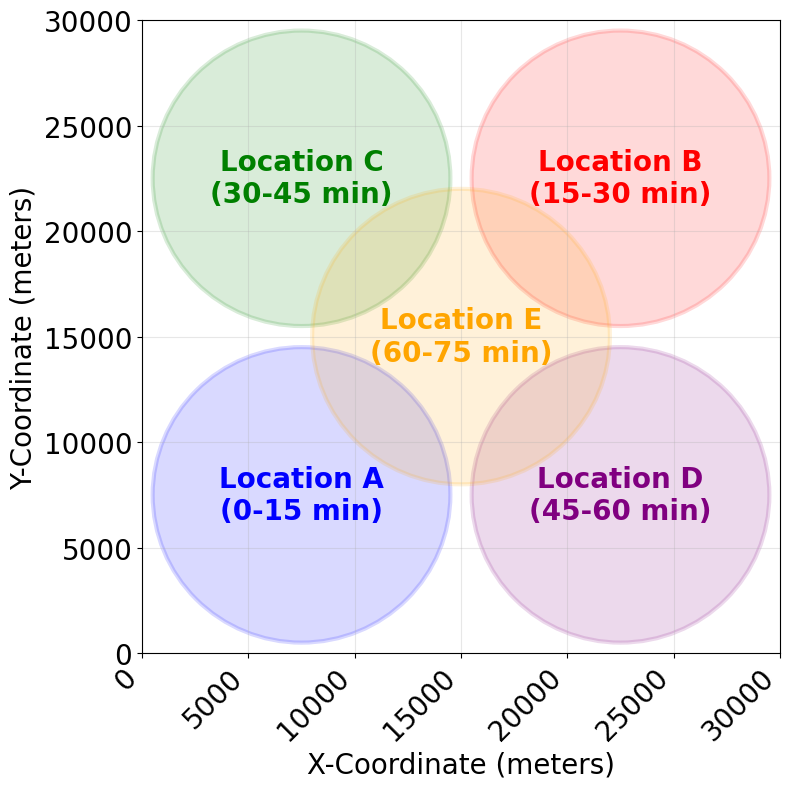

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load csv file
USER_CSV_PATH = 'Synthetic_Dataset/Dataset/Coverage_recover_and_degradation_analysis_200.csv'
user_df = pd.read_csv(USER_CSV_PATH)

regions = [
    (7500, 7500, 'A', 'blue', (0, 15)),
    (22500, 22500, 'B', 'red', (15, 30)),
    (7500, 22500, 'C', 'green', (30, 45)),
    (22500, 7500, 'D', 'purple', (45, 60)),
    (15000, 15000, 'E', 'orange', (60, 75)),
]
cluster_radius = 7000
fig1, ax1 = plt.subplots(figsize=(8, 8))

for cx, cy, label, color, (start, end) in regions:
    circle = patches.Circle(
        (cx, cy),
        cluster_radius,
        edgecolor=color,
        facecolor=color,
        alpha=0.15,
        lw=3
    )
    ax1.add_patch(circle)

    ax1.text(
        cx, cy,
        f'Location {label}\n({start}-{end} min)',
        color=color,
        fontsize=20,
        fontweight='bold',
        ha='center',
        va='center'
    )
ax1.set_xlim(0, 30000)
ax1.set_ylim(0, 30000)
ax1.set_xlabel('X-Coordinate (meters)', fontsize=20)
ax1.set_ylabel('Y-Coordinate (meters)', fontsize=20)
ax1.tick_params(axis='both', labelsize=20)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Sensitivity analysis with field size

#### Network Efficiency

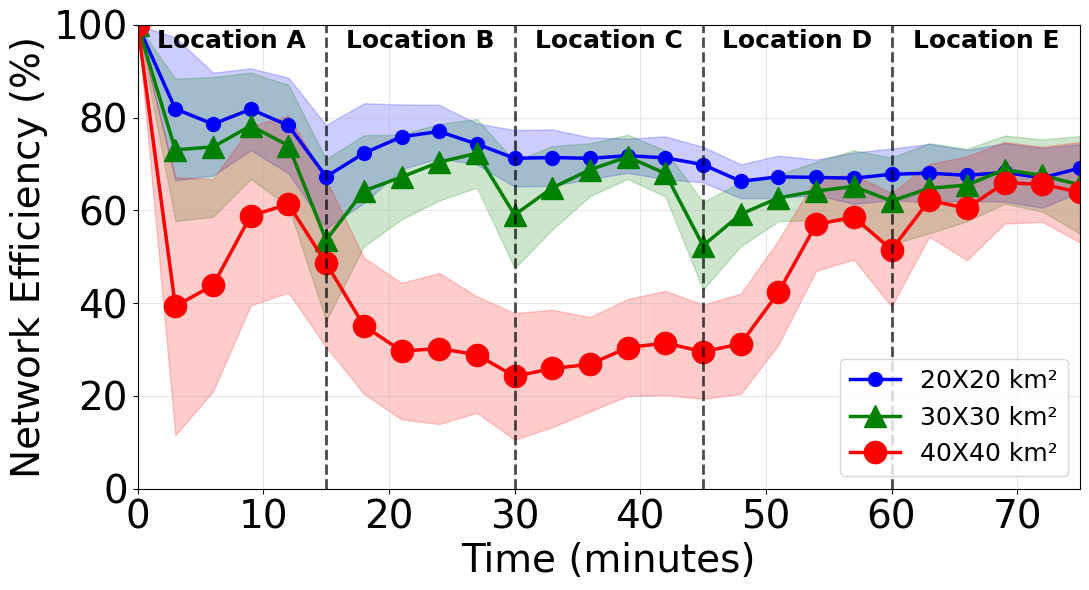

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load csv files

SENSITIVITY_CSVS = {
    20: 'results/NoFailure_SimPy_20260211_190440.csv',  
    30: 'results/NoFailure_SimPy_20260211_183103.csv',
    40: 'results/NoFailure_SimPy_20260211_183322.csv'
}

fig2, ax2 = plt.subplots(figsize=(11, 6))

STYLE_CONFIG = {
    20: {'color': 'blue',  'marker': 'o', 'size': 10},
    30: {'color': 'green', 'marker': '^', 'size': 16},
    40: {'color': 'red',   'marker': 'o', 'size': 16},
}

for users, csv_path in SENSITIVITY_CSVS.items():

    style = STYLE_CONFIG[users]
    sum_df = pd.read_csv(csv_path)
    sum_df['network_efficiency'] *= 100
    coverage_stats = (
        sum_df
        .groupby('timestamp')['network_efficiency']
        .agg(['mean', 'std'])
        .reset_index()
    )
    coverage_stats = coverage_stats[
        coverage_stats["timestamp"].round() % 3 == 0
    ]
    ax2.plot(
        coverage_stats['timestamp'],
        coverage_stats['mean'],
        linestyle='-',
        marker=style['marker'],
        color=style['color'],
        linewidth=2.5,
        markersize=style['size'],
        label=f'{users}X{users} km²'
    )
    ax2.fill_between(
        coverage_stats['timestamp'],
        coverage_stats['mean'] - coverage_stats['std'],
        coverage_stats['mean'] + coverage_stats['std'],
        color=style['color'],
        alpha=0.2
    )

ax2.set_xlim(0, 75)
ax2.set_ylim(0, 100)
ax2.margins(0)
ax2.set_xlabel('Time (minutes)', fontsize=28)
ax2.set_ylabel('Network Efficiency (%)', fontsize=28)
ax2.tick_params(axis='both', labelsize=28)
ax2.grid(alpha=0.3)

for _, _, label, color, (start, _) in regions[1:]:
    ax2.axvline(start, color='black', linestyle='--', linewidth=2, alpha=0.7)

for _, _, label, color, (start, end) in regions:
    ax2.text(
        (start + end) / 2,
        95,
        f'Location {label}',
        fontsize=18,
        fontweight='bold',
        ha='center'
    )
ax2.legend(
    fontsize=18,
    loc='lower right'
)
plt.tight_layout()
plt.show()


#### Ground User Coverage

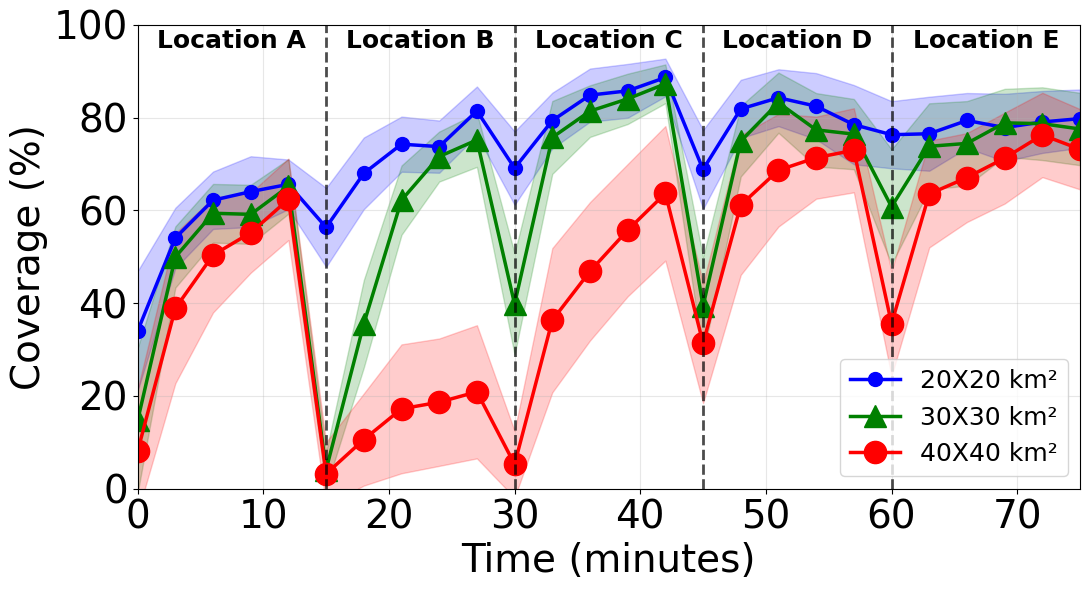

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load csv files
SENSITIVITY_CSVS = {
    20: 'results/NoFailure_SimPy_20260211_190440.csv',  
    30: 'results/NoFailure_SimPy_20260211_183103.csv',
    40: 'results/NoFailure_SimPy_20260211_183322.csv'
}

fig2, ax2 = plt.subplots(figsize=(11, 6))
STYLE_CONFIG = {
    20: {'color': 'blue',  'marker': 'o', 'size': 10},
    30: {'color': 'green', 'marker': '^', 'size': 16},
    40: {'color': 'red',   'marker': 'o', 'size': 16},
}

for users, csv_path in SENSITIVITY_CSVS.items():
    style = STYLE_CONFIG[users]
    sum_df = pd.read_csv(csv_path)

    coverage_column = [col for col in sum_df.columns if 'cover' in col.lower()]
    
    if not coverage_column:
        raise ValueError("No coverage column found in CSV file.")

    coverage_column = coverage_column[0]
    if sum_df[coverage_column].max() <= 1:
        sum_df[coverage_column] *= 100
    coverage_stats = (
        sum_df
        .groupby('timestamp')[coverage_column]
        .agg(['mean', 'std'])
        .reset_index()
    )
    coverage_stats = coverage_stats[
        coverage_stats["timestamp"].round() % 3 == 0
    ]
    ax2.plot(
        coverage_stats['timestamp'],
        coverage_stats['mean'],
        linestyle='-',
        marker=style['marker'],
        color=style['color'],
        linewidth=2.5,
        markersize=style['size'],
        label=f'{users}X{users} km²'
    )
    ax2.fill_between(
        coverage_stats['timestamp'],
        coverage_stats['mean'] - coverage_stats['std'],
        coverage_stats['mean'] + coverage_stats['std'],
        color=style['color'],
        alpha=0.2
    )
ax2.set_xlim(0, 75)
ax2.set_ylim(0, 100)
ax2.margins(0)

ax2.set_xlabel('Time (minutes)', fontsize=28)
ax2.set_ylabel('Coverage (%)', fontsize=28)

ax2.tick_params(axis='both', labelsize=28)
ax2.grid(alpha=0.3)

for _, _, _, _, (start, _) in regions[1:]:
    ax2.axvline(start, color='black', linestyle='--', linewidth=2, alpha=0.7)

for _, _, label, _, (start, end) in regions:
    ax2.text(
        (start + end) / 2,
        95,
        f'Location {label}',
        fontsize=18,
        fontweight='bold',
        ha='center'
    )

ax2.legend(fontsize=18, loc='lower right')

plt.tight_layout()
plt.show()


#### No of connected components

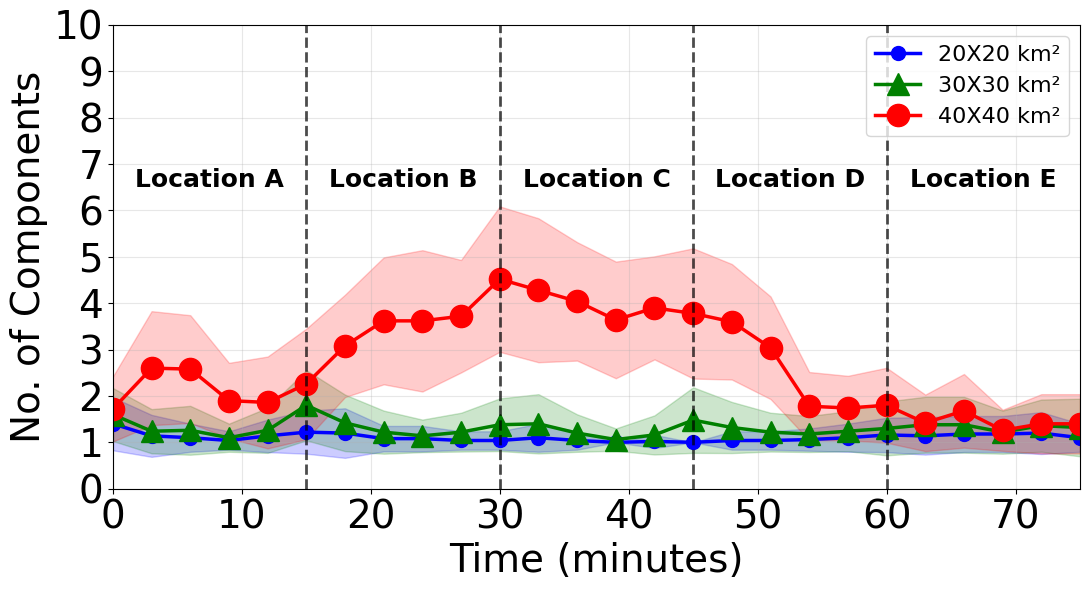

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load csv files

SENSITIVITY_CSVS = {
    20: 'results/NoFailure_SimPy_20260211_190440.csv',  
    30: 'results/NoFailure_SimPy_20260211_183103.csv',
    40: 'results/NoFailure_SimPy_20260211_183322.csv'
}


fig2, ax2 = plt.subplots(figsize=(11, 6))
STYLE_CONFIG = {
    20: {'color': 'blue',  'marker': 'o', 'size': 10},
    30: {'color': 'green', 'marker': '^', 'size': 16},
    40: {'color': 'red',   'marker': 'o', 'size': 16},
}

for users, csv_path in SENSITIVITY_CSVS.items():
    style = STYLE_CONFIG[users]
    sum_df = pd.read_csv(csv_path)
    coverage_stats = (
        sum_df
        .groupby('timestamp')['num_components']
        .agg(['mean', 'std'])
        .reset_index()
    )
    coverage_stats = coverage_stats[
        coverage_stats["timestamp"].round() % 3 == 0
    ] 
    ax2.plot(
        coverage_stats['timestamp'],
        coverage_stats['mean'],
        linestyle='-',
        marker=style['marker'],
        color=style['color'],
        linewidth=2.5,
        markersize=style['size'],
        label=f'{users}X{users} km²'
    )
    ax2.fill_between(
        coverage_stats['timestamp'],
        coverage_stats['mean'] - coverage_stats['std'],
        coverage_stats['mean'] + coverage_stats['std'],
        color=style['color'],
        alpha=0.2
    )
ax2.set_xlim(0, 75)
ax2.set_ylim(0, 10)
ax2.set_yticks(range(0, 11))
ax2.set_xlabel('Time (minutes)', fontsize=28)
ax2.set_ylabel('No. of Components', fontsize=28)
ax2.tick_params(axis='both', labelsize=28)
ax2.grid(alpha=0.3)
for _, _, label, color, (start, _) in regions[1:]:
    ax2.axvline(start, color='black', linestyle='--', linewidth=2, alpha=0.7)
for _, _, label, color, (start, end) in regions:
    ax2.text(
        (start + end) / 2,
        6.5,  #  inside y-limit
        f'Location {label}',
        fontsize=18,
        fontweight='bold',
        ha='center'
    )
ax2.legend(
    fontsize=16,
    loc='upper right'
)
plt.tight_layout()
plt.show()


# Sensitivity analysis by changing the number of users from 100 to 300.

#### coverage

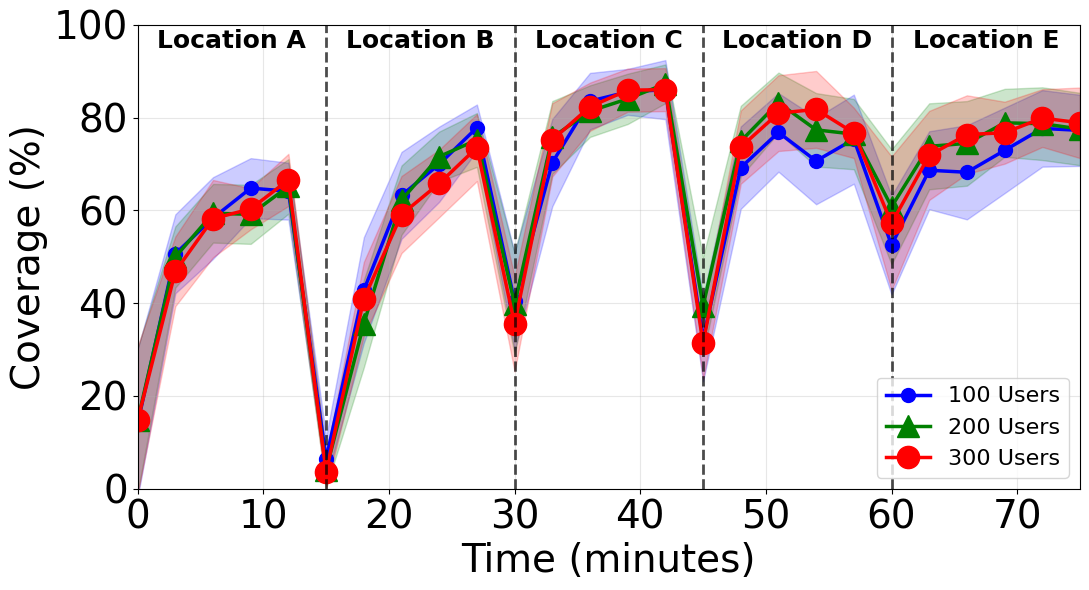

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load csv files

SENSITIVITY_CSVS = {    
100: 'results/NoFailure_SimPy_20260210_172227.csv',
200: 'results/NoFailure_SimPy_20260210_171844.csv',
300: 'results/NoFailure_SimPy_20260210_172625.csv'
}

fig2, ax2 = plt.subplots(figsize=(11, 6))

STYLE_CONFIG = {
    100: {'color': 'blue',  'marker': 'o', 'size': 10},
    200: {'color': 'green', 'marker': '^', 'size': 16},
    300: {'color': 'red',   'marker': 'o', 'size': 16},
}

for users, csv_path in SENSITIVITY_CSVS.items():

    style = STYLE_CONFIG[users]
    
    sum_df = pd.read_csv(csv_path)

    coverage_stats = (
        sum_df
        .groupby('timestamp')[coverage_column]
        .agg(['mean', 'std'])
        .reset_index()
    )
    coverage_stats = coverage_stats[
        coverage_stats["timestamp"].round() % 3 == 0
    ]
    ax2.plot(
        coverage_stats['timestamp'],
        coverage_stats['mean'],
        linestyle='-',
        marker=style['marker'],
        color=style['color'],
        linewidth=2.5,
        markersize=style['size'],
        label=f'{users} Users'
    )
    ax2.fill_between(
        coverage_stats['timestamp'],
        coverage_stats['mean'] - coverage_stats['std'],
        coverage_stats['mean'] + coverage_stats['std'],
        color=style['color'],
        alpha=0.2
    )
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)
ax2.set_xlim(0,75)
ax2.margins(0)

ax2.set_xlabel('Time (minutes)', fontsize=28)
ax2.set_ylabel('Coverage (%)', fontsize=28)

ax2.tick_params(axis='both', labelsize=28)
ax2.grid(alpha=0.3)

ax2.text(
    ax2.get_xlim()[1] * 0.99,
    80.5,
    '',
    color='red',
    fontsize=16,
    fontweight='bold',
    ha='right',
    va='bottom'
)
for _, _, _, _, (start, _) in regions[1:]:
    ax2.axvline(start, color='black', linestyle='--', linewidth=2, alpha=0.7)

for _, _, label, _, (start, end) in regions:
    ax2.text(
        (start + end) / 2,
        95,
        f'Location {label}',
        fontsize=18,
        fontweight='bold',
        ha='center'
    )
ax2.legend(
    title='',
    fontsize=16,
    title_fontsize=18,
    loc='lower right'
)

plt.tight_layout()
plt.show()



#### No of connected components

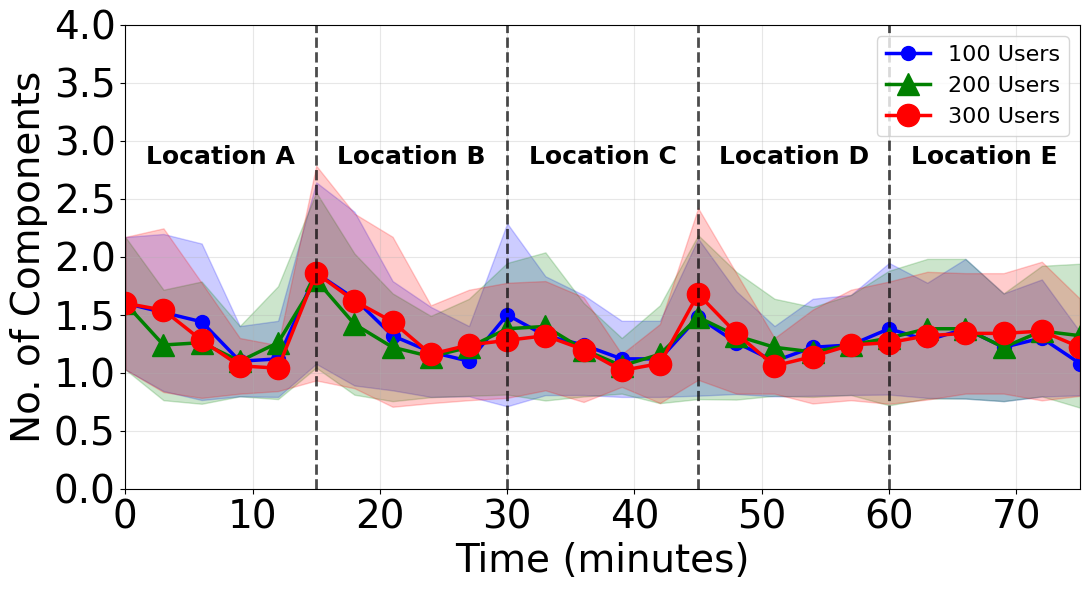

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load csv files

SENSITIVITY_CSVS = {
    100: 'results/NoFailure_SimPy_20260210_172227.csv',
    200: 'results/NoFailure_SimPy_20260210_171844.csv',
    300: 'results/NoFailure_SimPy_20260210_172625.csv'
}


fig2, ax2 = plt.subplots(figsize=(11, 6))
STYLE_CONFIG = {
    100: {'color': 'blue',  'marker': 'o', 'size': 10},
    200: {'color': 'green', 'marker': '^', 'size': 16},
    300: {'color': 'red',   'marker': 'o', 'size': 16},
}

for users, csv_path in SENSITIVITY_CSVS.items():
    style = STYLE_CONFIG[users]
    sum_df = pd.read_csv(csv_path)
    coverage_stats = (
        sum_df
        .groupby('timestamp')['num_components']
        .agg(['mean', 'std'])
        .reset_index()
    )
    coverage_stats = coverage_stats[
        coverage_stats["timestamp"].round() % 3 == 0
    ]
    ax2.plot(
        coverage_stats['timestamp'],
        coverage_stats['mean'],
        linestyle='-',
        marker=style['marker'],
        color=style['color'],
        linewidth=2.5,
        markersize=style['size'],
        label=f'{users} Users'
    )
    ax2.fill_between(
        coverage_stats['timestamp'],
        coverage_stats['mean'] - coverage_stats['std'],
        coverage_stats['mean'] + coverage_stats['std'],
        color=style['color'],
        alpha=0.2
    )
ax2.set_xlim(0, 75)
ax2.set_ylim(0, 4) 
ax2.set_yticks([0, 0.5, 1.0, 1.5, 2.0,2.5,3.0,3.5,4.0])  
ax2.margins(0)
ax2.set_xlabel('Time (minutes)', fontsize=28)
ax2.set_ylabel('No. of Components', fontsize=28)  
ax2.tick_params(axis='both', labelsize=28)
ax2.grid(alpha=0.3)

for _, _, label, color, (start, _) in regions[1:]:
    ax2.axvline(start, color='black', linestyle='--', linewidth=2, alpha=0.7)
    
for _, _, label, color, (start, end) in regions:
    ax2.text(
        (start + end) / 2,
        2.8,  #  inside y-limit
        f'Location {label}',
        fontsize=18,
        fontweight='bold',
        ha='center'
    )
ax2.legend(
    title='',
    fontsize=16,
    title_fontsize=18,
    loc='upper right'  
)

plt.tight_layout()
plt.show()



#### Network efficiency

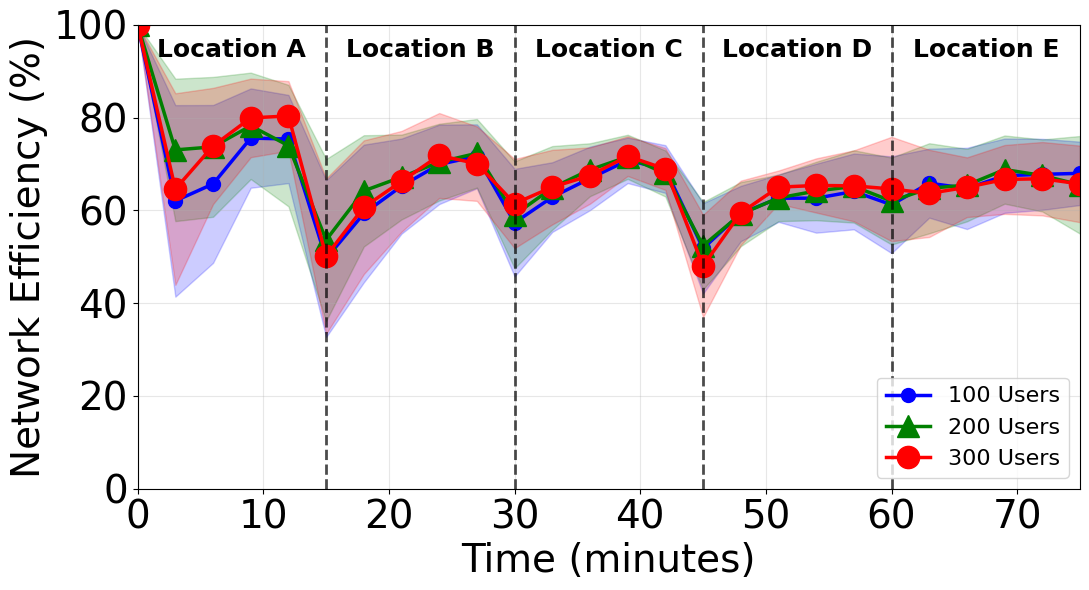

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load csv files

SENSITIVITY_CSVS = {
    100: 'results/NoFailure_SimPy_20260210_172227.csv',
    200: 'results/NoFailure_SimPy_20260210_171844.csv',
    300: 'results/NoFailure_SimPy_20260210_172625.csv'
}

fig2, ax2 = plt.subplots(figsize=(11, 6))
STYLE_CONFIG = {
    100: {'color': 'blue',  'marker': 'o', 'size': 10},
    200: {'color': 'green', 'marker': '^', 'size': 16},
    300: {'color': 'red',   'marker': 'o', 'size': 16},
}
for users, csv_path in SENSITIVITY_CSVS.items():
    style = STYLE_CONFIG[users]
    sum_df = pd.read_csv(csv_path)
    sum_df['network_efficiency'] = sum_df['network_efficiency'] * 100
    coverage_stats = (
        sum_df
        .groupby('timestamp')['network_efficiency']
        .agg(['mean', 'std'])
        .reset_index()
    )
    coverage_stats = coverage_stats[
        coverage_stats["timestamp"].round() % 3 == 0
    ]
    ax2.plot(
        coverage_stats['timestamp'],
        coverage_stats['mean'],
        linestyle='-',
        marker=style['marker'],
        color=style['color'],
        linewidth=2.5,
        markersize=style['size'],
        label=f'{users} Users'
    )
    ax2.fill_between(
        coverage_stats['timestamp'],
        coverage_stats['mean'] - coverage_stats['std'],
        coverage_stats['mean'] + coverage_stats['std'],
        color=style['color'],
        alpha=0.2
    )
ax2.set_xlim(0, 75)
ax2.set_ylim(0, 100)
ax2.margins(0)
ax2.set_xlabel('Time (minutes)', fontsize=28)
ax2.set_ylabel('Network Efficiency (%)', fontsize=28)
ax2.tick_params(axis='both', labelsize=28)
ax2.grid(alpha=0.3)
for _, _, label, color, (start, _) in regions[1:]:
    ax2.axvline(start, color='black', linestyle='--', linewidth=2, alpha=0.7)
y_top = ax2.get_ylim()[1] * 0.93

for _, _, label, color, (start, end) in regions:
    ax2.text(
        (start + end) / 2,
        y_top,
        f'Location {label}',
        fontsize=18,
        fontweight='bold',
        ha='center'
    )

ax2.legend(fontsize=16, loc='lower right')

plt.tight_layout()
plt.show()
